In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from heston.pinn.heston_pinn import HestonPINN
from utility.model import ModelConfig, EarlyStopping

In [1]:
K = 1.0
r = 0.1
T = 1.0
kappa = 2.0
theta = 0.04
sigma = 0.3
rho = -0.7

S_min = 0.0
S_max = 3 * K

V_min = 0.0
V_max = 0.8

In [3]:
input_size = 3
hidden_sizes = [64, 64, 64]
output_size = 1
activation = nn.Sigmoid()
learning_rate = 0.001

# Scheduler
step_size = 2000
gamma = 0.7

model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate,
    step_size=step_size,
    gamma=gamma
)

loss_weights = {
    'variational': 5,
    'terminal': 5,
    'Smin': 3,
    'Smax': 3,
    'Vmin': 3,
    'Vmax': 3
}

In [4]:
seed = 42
pinn = HestonPINN(model_config, seed)
pinn.set_params(K, r, T, kappa, theta, sigma, rho, S_min, S_max, V_min, V_max)
pinn.set_loss_weights(loss_weights)

early_stopping = EarlyStopping(patience=500, min_delta=1e-6)
pinn.train(batch_size=4096, epochs=30000, early_stopping=early_stopping)

Iteration 0 | Training Loss: 0.24037182331085205 | Validation Loss: 0.21180275082588196
Iteration 500 | Training Loss: 0.002512101549655199 | Validation Loss: 0.0023854924365878105
Iteration 1000 | Training Loss: 0.0004515120526775718 | Validation Loss: 0.00044094418990425766
Iteration 1500 | Training Loss: 0.00027998577570542693 | Validation Loss: 0.0002777781628537923
Iteration 2000 | Training Loss: 0.00025943515356630087 | Validation Loss: 0.0002494481159374118
Iteration 2500 | Training Loss: 0.00023188865452539176 | Validation Loss: 0.0002353692689212039
Iteration 3000 | Training Loss: 0.00022016296861693263 | Validation Loss: 0.00021793365885969251
Iteration 3500 | Training Loss: 0.00019999417418148369 | Validation Loss: 0.0001971339079318568
Iteration 4000 | Training Loss: 0.00018401528359390795 | Validation Loss: 0.00017259360174648464
Iteration 4500 | Training Loss: 0.00016108494310174137 | Validation Loss: 0.00015693072055000812
Iteration 5000 | Training Loss: 0.00015395223454

NotImplementedError: Training loop not implemented yet

In [6]:
pinn.save(f'../models/heston_pinn_1d/{seed}.pth')


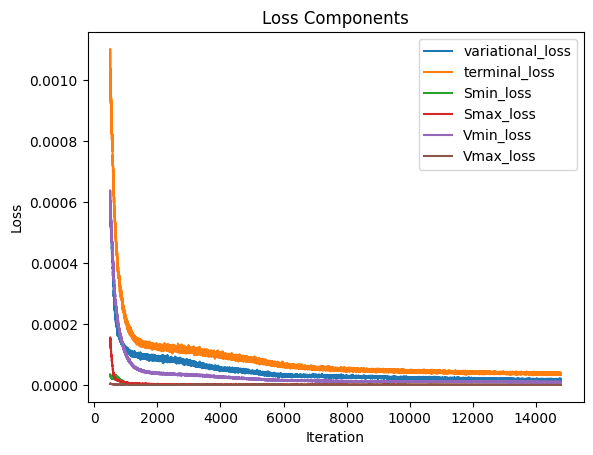

In [9]:
pinn.plot_losses(start_epoch=500, detailed=True)